<a href="https://colab.research.google.com/github/Setobama/fraud-detection-anomaly/blob/main/fraud_detection_anomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 1. IMPORT LIBRARIES

In [16]:
# Core libraries
import pandas as pd
import numpy as np
import gdown

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix


In [17]:
import gdown

file_id = "1tqCoMiZTBLwCPWM3D9NJpmKaUh7B7Ckc"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "creditcard.csv", quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1tqCoMiZTBLwCPWM3D9NJpmKaUh7B7Ckc
From (redirected): https://drive.google.com/uc?id=1tqCoMiZTBLwCPWM3D9NJpmKaUh7B7Ckc&confirm=t&uuid=58ede491-e07d-4f9b-848e-0d8aba2efa9e
To: /content/creditcard.csv
100%|██████████| 151M/151M [00:01<00:00, 80.7MB/s]


'creditcard.csv'

#2. LOAD DATA

In [23]:
df = pd.read_csv("creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#3. BASIC EXPLORATION

In [24]:
print("Shape:", df.shape)
print(df.describe())

# Check class distribution
df['Class'].value_counts()


Shape: (284807, 31)
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1

,count
Class,
0,284315
1,492


4. FEATURE SCALING

In [26]:
scaler = StandardScaler()

X = df.drop('Class', axis=1)
y = df['Class']

X_scaled = scaler.fit_transform(X)


# Unsupervised Anomaly Detection

#5. TRAIN ISOLATION FOREST

In [27]:
iso = IsolationForest(
    contamination=0.001,  # expected fraud ratio
    random_state=42,
    n_estimators=200,
    max_samples='auto'
)

iso.fit(X_scaled)

# Predict anomalies (-1 = anomaly, 1 = normal)
y_pred_iso = iso.predict(X_scaled)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)


#6. TRAIN ONE‑CLASS SVM

In [28]:
ocsvm = OneClassSVM(
    kernel='rbf',
    gamma=0.001,
    nu=0.001
)

ocsvm.fit(X_scaled)

y_pred_svm = ocsvm.predict(X_scaled)
y_pred_svm = np.where(y_pred_svm == -1, 1, 0)


7. EVALUATE MODELS

In [29]:
print("=== Isolation Forest ===")
print(classification_report(y, y_pred_iso))

print("=== One-Class SVM ===")
print(classification_report(y, y_pred_svm))


=== Isolation Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.29      0.17      0.22       492

    accuracy                           1.00    284807
   macro avg       0.65      0.59      0.61    284807
weighted avg       1.00      1.00      1.00    284807

=== One-Class SVM ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.18      0.10      0.13       492

    accuracy                           1.00    284807
   macro avg       0.59      0.55      0.56    284807
weighted avg       1.00      1.00      1.00    284807



#8. CONFUSION MATRIX

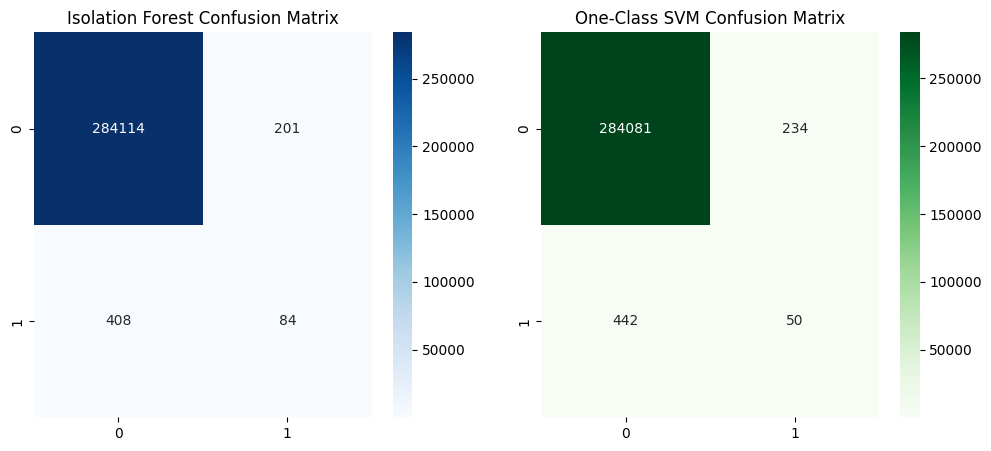

In [30]:
cm_iso = confusion_matrix(y, y_pred_iso)
cm_svm = confusion_matrix(y, y_pred_svm)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Blues')
plt.title("Isolation Forest Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title("One-Class SVM Confusion Matrix")

plt.show()


In [ ]:
9. VISUALISE ANOMALIES

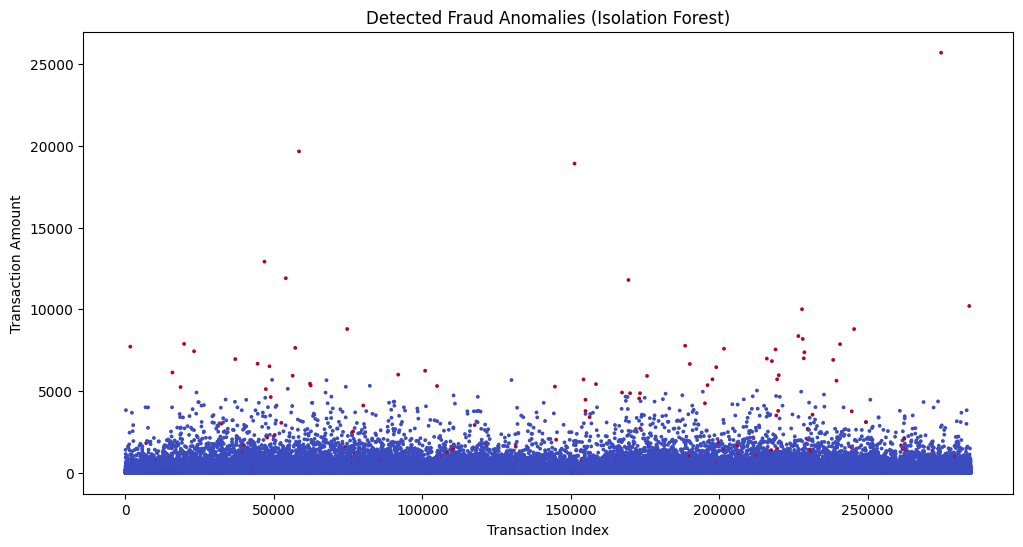

In [31]:
plt.figure(figsize=(12,6))
plt.scatter(df.index, df['Amount'], c=y_pred_iso, cmap='coolwarm', s=3)
plt.title("Detected Fraud Anomalies (Isolation Forest)")
plt.xlabel("Transaction Index")
plt.ylabel("Transaction Amount")
plt.show()


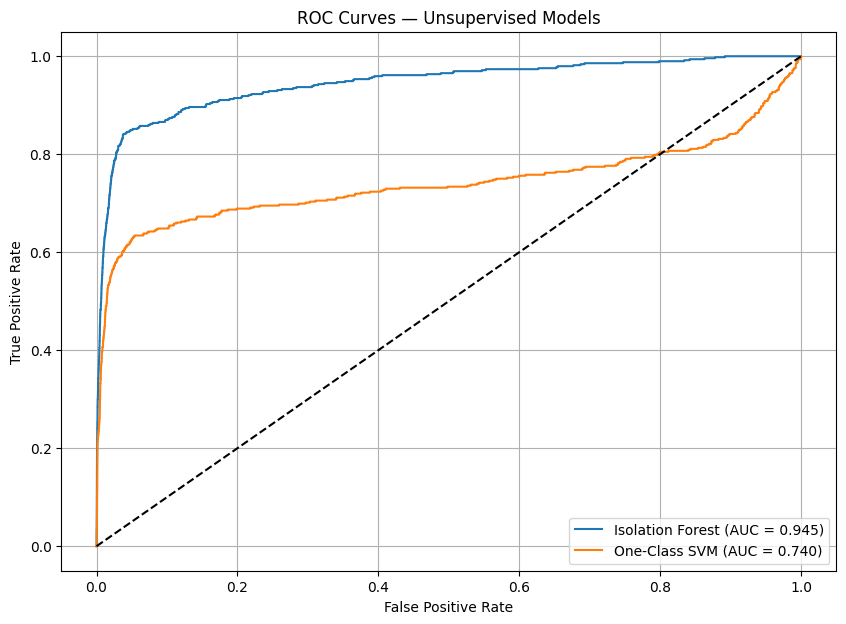

In [43]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get anomaly scores (higher = more fraud)
iso_scores = -iso.decision_function(X_scaled)
svm_scores = -ocsvm.decision_function(X_scaled)

# Compute ROC
fpr_iso, tpr_iso, _ = roc_curve(y, iso_scores)
fpr_svm, tpr_svm, _ = roc_curve(y, svm_scores)

auc_iso = auc(fpr_iso, tpr_iso)
auc_svm = auc(fpr_svm, tpr_svm)

# Plot
plt.figure(figsize=(10,7))
plt.plot(fpr_iso, tpr_iso, label=f"Isolation Forest (AUC = {auc_iso:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"One-Class SVM (AUC = {auc_svm:.3f})")
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curves — Unsupervised Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


## 2. Supervised Learning Models


In [32]:
df = pd.read_csv("creditcard.csv")


In [33]:
y = df["Class"]
X = df.drop("Class", axis=1)


#🟦 STEP 1 — Train/Test Split + Scaling

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("Class", axis=1)
y = df["Class"]

# Stratified split preserves fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


🟦 STEP 2 — Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=500, class_weight="balanced")
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


=== Logistic Regression ===
[[55478  1386]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



🟦 STEP 3 — Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


=== Random Forest ===
[[56861     3]
 [   23    75]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.77      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



# STEP 4 — XGBoost (Best Performer)

In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),  # handles imbalance
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


=== XGBoost ===
[[56851    13]
 [   17    81]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



# Supervised Confusion Matrix Plot

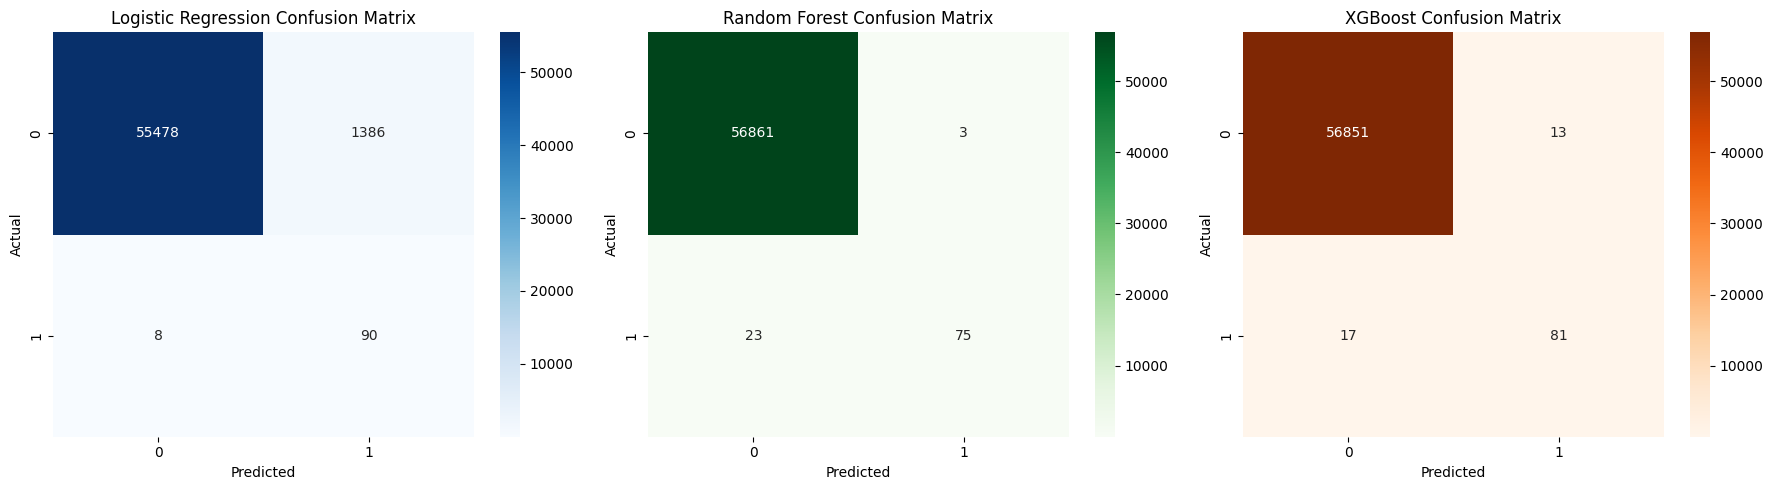

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrices for supervised models
cm_lr  = confusion_matrix(y_test, y_pred_lr)
cm_rf  = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(18,5))

# Logistic Regression
plt.subplot(1,3,1)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Random Forest
plt.subplot(1,3,2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# XGBoost
plt.subplot(1,3,3)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


In [40]:
# Get anomaly scores (higher = more normal, lower = more anomalous)
iso_scores = -iso_model.decision_function(X)   # invert so higher = more fraud
svm_scores = -svm_model.decision_function(X)

# Compute ROC
fpr_iso, tpr_iso, _ = roc_curve(y, iso_scores)
fpr_svm, tpr_svm, _ = roc_curve(y, svm_scores)

auc_iso = auc(fpr_iso, tpr_iso)
auc_svm = auc(fpr_svm, tpr_svm)

# Plot
plt.figure(figsize=(10,7))
plt.plot(fpr_iso, tpr_iso, label=f"Isolation Forest (AUC = {auc_iso:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"One-Class SVM (AUC = {auc_svm:.3f})")
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curves — Unsupervised Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'iso_model' is not defined

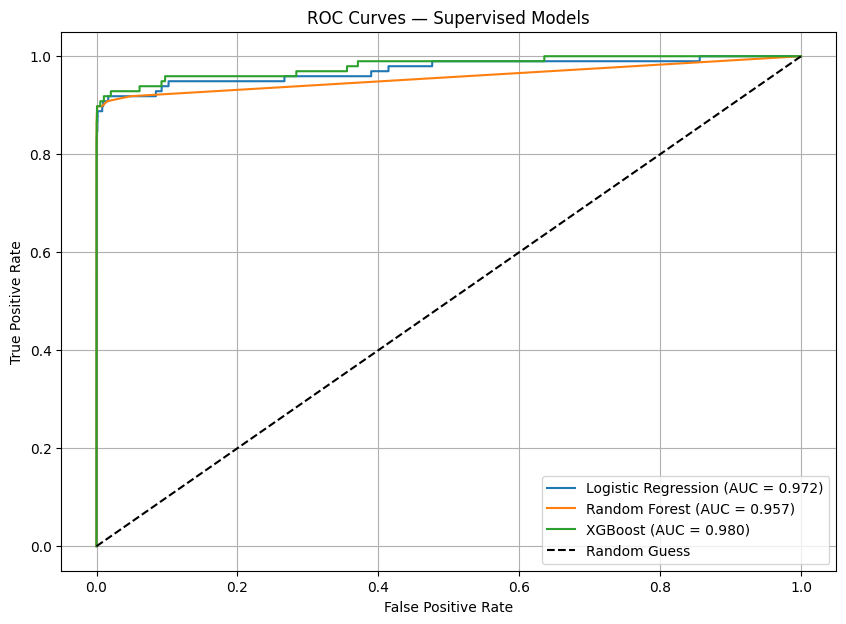

In [39]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y_prob_lr  = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_rf  = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Compute AUC
auc_lr  = auc(fpr_lr, tpr_lr)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot
plt.figure(figsize=(10,7))
plt.plot(fpr_lr,  tpr_lr,  label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.title("ROC Curves — Supervised Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()
